# Physics 234 Final
## April 24, 2024  9-12 AM

Do the following problems. Use the Jupyter notebook, inserting your code and any textual answers/explanations in cells between the questions. (Feel free to add additional cells!) Marks will be given based on how clearly you demonstrate your understanding.

There are no restrictions on downloading from the internet, eclass, or the use of books, notes, or any other widely available computing resources. However, you are not allowed to communicate with others or collaborate in any way and uploading to the internet or sending or receiving direct communications is not appropriate. AI engines like ChatGPT are not appropriate.  

When you are finished, upload the jupyter notebook to eclass. Eclass times out at 12:00 so make sure that you upload things before then. Also be careful to save the notebook periodically and that you upload the file that contains all your work.

# 1. Black body spectrum

The number of photons per second, $N_\lambda$, emitted by a black body of absolute temperature T and of area $A$, into a photon-wavelength interval $d\lambda$ and a solid angle $d\Omega$ is
$${\displaystyle \frac{d^2N_{\lambda }(\lambda ,T)}{d\lambda d\Omega}={\frac {2A c}{\lambda^{4}}}{\frac {1}{\exp \left({\frac {hc}{\lambda k_{\mathrm {B} }T}}\right)-1}}}$$

An experiment is set up  to observe the black body. The photon detector subtends solid angle $\Omega$, so the photon rate becomes:
$${\displaystyle \frac{dN_{\lambda }(\lambda ,T)}{d\lambda}={\frac {2A\Omega c}{\lambda^{4}}}{\frac {1}{\exp \left({\frac {hc }{\lambda k_{\mathrm {B} }T}}\right)-1}}}$$

Here $c$ is the speed of light, $h$ is Plank's constant, and $k_B$ is the Boltzmann constant.   

1a. Set $A\Omega=0.0001~\rm{m}^2, T=6000~\rm{K}.$  Write a function dN(l,T) that calculates $\frac{dN_\lambda}{d\lambda}$ for photons of wavelength l, and plot it over a reasonable range. Overlay the plot with $T=6500~\rm{K}$.  Then plot the ratio. 

c=299792458.0 m/s, h=6.62607015e-34 Js, k=1.380649e-23 J/K


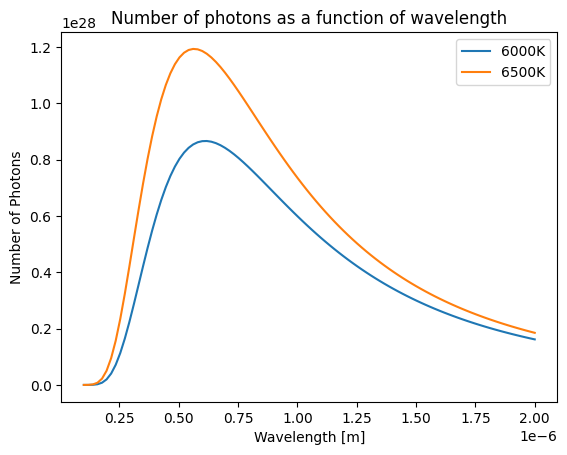

Text(0, 0.5, 'Number of Photons at 6500K/6000K')

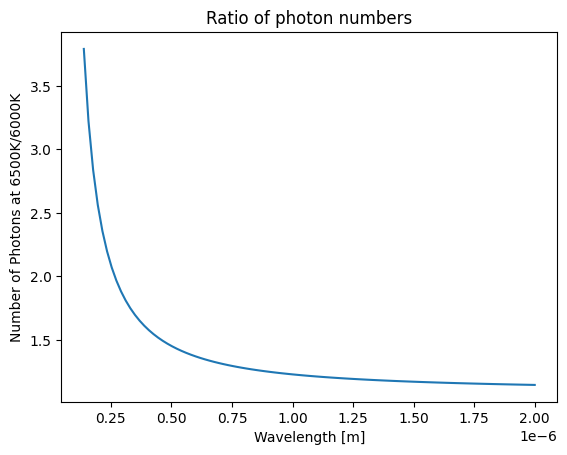

In [3]:
from scipy.constants import c,h,k
import numpy as np
import matplotlib.pyplot as plt

AO=1e-4
def dN(l,T):  # note-- if l is in nm, need to multiply be 1e-9 before plugging into the next line.
    return 2*c*AO/(l**4*(np.exp(h*c/l/k/T)-1))

print(f'c={c} m/s, h={h} Js, k={k} J/K')
llist=np.linspace(100e-9,2000e-9,100)
plt.plot(llist,dN(llist,6000),label='6000K')
plt.plot(llist,dN(llist,6500),label='6500K')
plt.legend()
plt.title('Number of photons as a function of wavelength')
plt.xlabel('Wavelength [m]')
plt.ylabel("Number of Photons")
plt.show()
plt.plot(llist[2:],dN(llist[2:],6500)/dN(llist[2:],6000))
plt.title('Ratio of photon numbers')
plt.xlabel('Wavelength [m]')
plt.ylabel("Number of Photons at 6500K/6000K")


1b. Define another function, the numerical derivative of the spectrum, and plot it for 6000 and 6500K. Using the numerical derivative, find the wavelength at which the dN function is maximum for T=6000 and 6500 K.  

 Maximum at T=6000 is 8.667529633751129e+27photons/sec at wavelength= 6.116171442019323e-07 m
 Maximum at T=6500 is 1.1938334966703611e+28photons/sec at wavelength= 5.6456967157742e-07 m


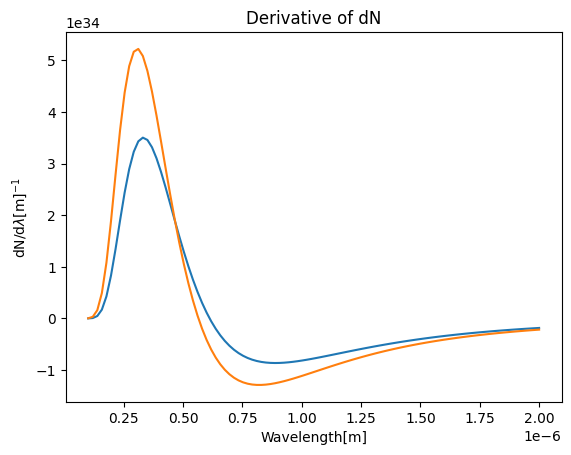

In [4]:
from scipy.optimize import root
def deriv(x,T):
    return (dN(x+5e-12,T)-dN(x-5e-12,T))/((x+5e-12)-(x-5e-12))  #when x is e-6 m, need e-12 steps
plt.plot(llist,deriv(llist,6000))
plt.plot(llist,deriv(llist,6500))
plt.title("Derivative of dN")
plt.xlabel("Wavelength[m]")
plt.ylabel("dN/d$\lambda$[m]$^{-1}$")


for T in (6000,6500):
    lmax=root(deriv,6e-7,args=(T,)).x[0]
    print(f' Maximum at T={T} is {dN(lmax,T)}photons/sec at wavelength= {lmax} m')


1c. Integrate dN to get the total number of photons, and plot it for temperatures between 100 and 7000K. 

Text(0, 0.5, 'Number of photons')

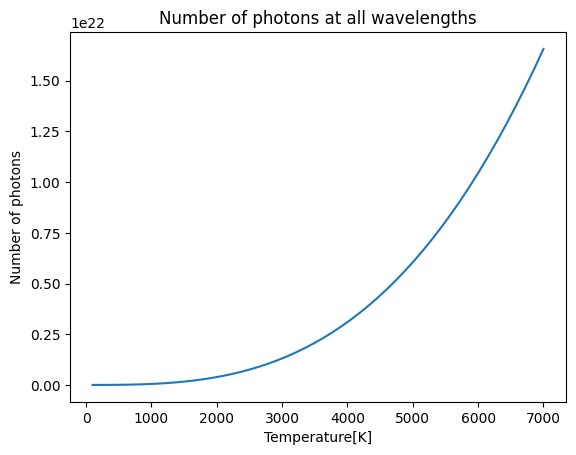

In [5]:
from scipy.integrate import quad
quad(dN,1e-7,0.01,args=6000)
tlist=np.linspace(100,7000)
plt.plot(tlist,[quad(dN,2e-7,0.001,args=t)[0] for t in tlist])
plt.title("Number of photons at all wavelengths")
plt.xlabel("Temperature[K]")
plt.ylabel("Number of photons")

1d.  One can also integrate dN using solve_ivp.  This is the same as doing an indefinite integral, since $$G(\lambda)=\int_{\lambda min}^{\lambda} f(x)dx\implies \frac {dG}{d\lambda}=f(\lambda).$$  Consequently, one can find $G(\lambda)$ numerically by using solve_ivp (after rewriting dN slightly); if one uses dense output we directly get an interpolation for $G(\lambda)$.

Do this at 6000 K and plot the integrated number of photons as a function of wavelength.  Pick the starting wavelength and the integration interval so that you include almost all the photons.   


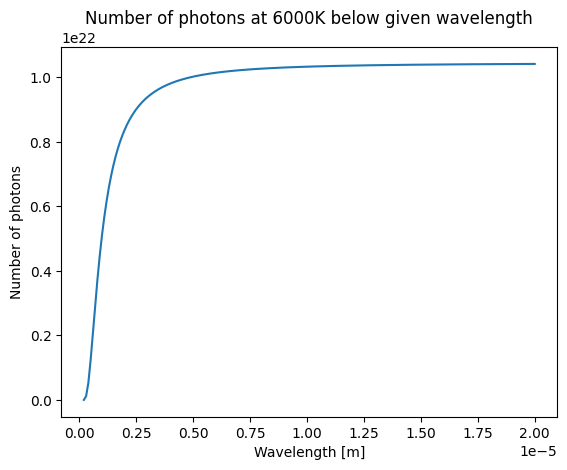

In [6]:
from scipy.integrate import solve_ivp
sol=solve_ivp(lambda l,y:dN(l,6000),(2.e-7,5e-5),[0],dense_output=True,method='DOP853',rtol=1e-8)
tlist=np.linspace(2e-7,2e-5,200)
plt.plot(tlist,sol.sol(tlist)[0])
plt.title('Number of photons at 6000K below given wavelength')
plt.xlabel('Wavelength [m]')
plt.ylabel("Number of photons")
plt.show()


1e. Generate 100,000 photons according to the $dN_\lambda/d\lambda$ distribution and plot the histogram. Overlay the dN function, scaled so the two distributions roughly match in maximum amplitude. 

Text(0, 0.5, 'Number of photons')

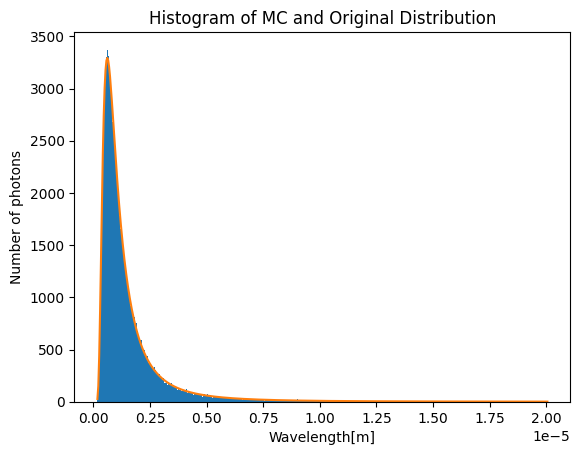

In [17]:
#Solution 1:  Throw and pick
rng=np.random.default_rng()
N=2000000 # samples needs to be big enough so that photons is more than 100000 long.
wl=rng.uniform(size=N)*2e-5+100E-9  #pick wavelengths from 1E-7-1e-5 m
prob=dN(wl,6000)
test=rng.uniform(size=N)*1e28  #1e28 from looking at the plot of dN at 6000
photons=wl[np.asarray(prob>test).nonzero()][:100000]
hist,b,h2=plt.hist(photons,500)
bc=(b[1:]+b[:-1])/2
plt.plot(bc,dN(bc,6000)*3.8e-25)
plt.title("Histogram of MC and Original Distribution")
plt.xlabel('Wavelength[m]')
plt.ylabel("Number of photons")

array([1.04337405e+12, 1.31173227e+11, 4.25768712e+10, ...,
       2.03537036e+11, 5.81340746e+13, 7.17356354e+10])

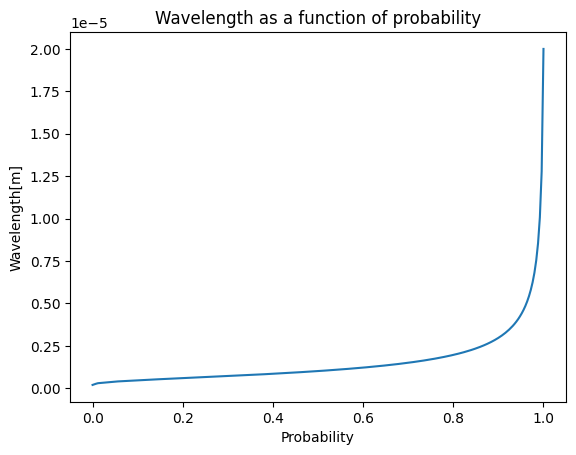

Text(0, 0.5, 'Number of photons')

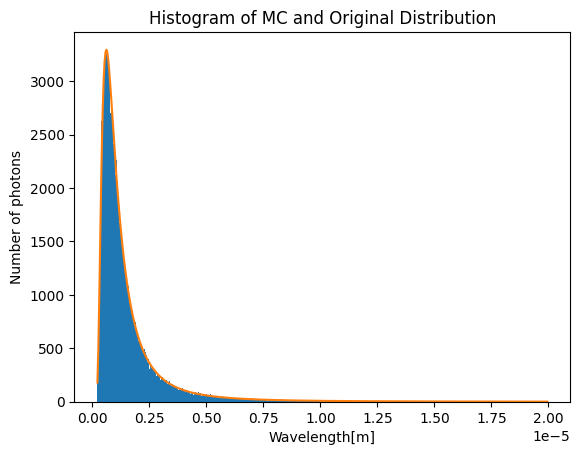

In [18]:
# Solution 2-- generate cdf, invert and throw probabilities
#we invert the distribution by interpolating (y,x) after changing distribution to a PDF by dividing by total 
# number of photons at all wavelengths
from scipy.interpolate import interp1d  
factor=sol.sol(tlist[-1])[0]
wlp=interp1d(sol.sol(tlist)[0]/factor,tlist,kind='linear') #wavelength as a function of probability
plist=np.linspace(0,1,250)
plt.plot(plist,wlp(plist))
plt.title("Wavelength as a function of probability")
plt.xlabel("Probability")
plt.ylabel("Wavelength[m]")
plt.show()
rng=np.random.default_rng()
l=rng.uniform(size=100000)
wl=wlp(l)
hist,b,h2=plt.hist(wl,500)
bc=(b[1:]+b[:-1])/2
plt.plot(bc,dN(bc,6000)*3.8e-25)
plt.title("Histogram of MC and Original Distribution")
plt.xlabel('Wavelength[m]')
plt.ylabel("Number of photons")

1f. The probability our detector will detect a photon of wavelength $\lambda$ is given by $$P(\lambda)=\begin{cases} 0, \lambda <400~\rm{nm}\\ 0.8e^{-\frac{\lambda-400}{100}},\lambda>400 \rm{nm} \end{cases}$$

How many of the 100000 photons would you detect? 

In [49]:
cut=rng.uniform(size=100000)
wlc=0.8*np.exp(-(wl-4e-7)/1e-7)
ndetected=(np.asarray(wl>4e-7)*np.asarray(wlc>cut)).nonzero()[0].shape[0]
print(f'We would detect {ndetected} photons')

We would detect 5846 photons


1g. Repeat the experiment many times, and plot the distribution of detected photons.  

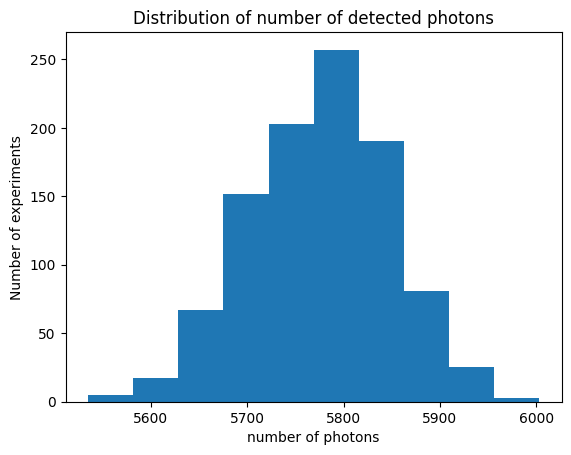

In [53]:
n=[]
for i in range(0,1000):
    wl=wlp(rng.uniform(size=100000))
    cut=rng.uniform(size=100000)
    wlc=0.8*np.exp(-(wl-4e-7)/1e-7)
    ndetected=(np.asarray(wl>4e-7)*np.asarray(wlc>cut)).nonzero()[0].shape[0]
    n.append(ndetected)

plt.hist(n)
plt.xlabel("number of photons")
plt.ylabel("Number of experiments")
plt.title("Distribution of number of detected photons")
plt.show()

## 2. A Falling Pole

A thin rigid pole 10 m tall and 100 kg in mass starts out at rest.  The bottom of the pole is on a frictionless pivot (a hinge attached to the ground).  The pole starts out at an angle $\theta_0$ from vertical, and is released at time t=0.  

2a.  Calculate when the pole hits the ground for a given $\theta_0$, and print out the solutions for $\theta_0=0.0001, 0.001,0.01, 0.1$ radians.  For each starting angle plot the angle $\theta$, the horizontal force,$F_x$  and the vertical force, $F_z$ as a function of time during the time the pole is falling.  

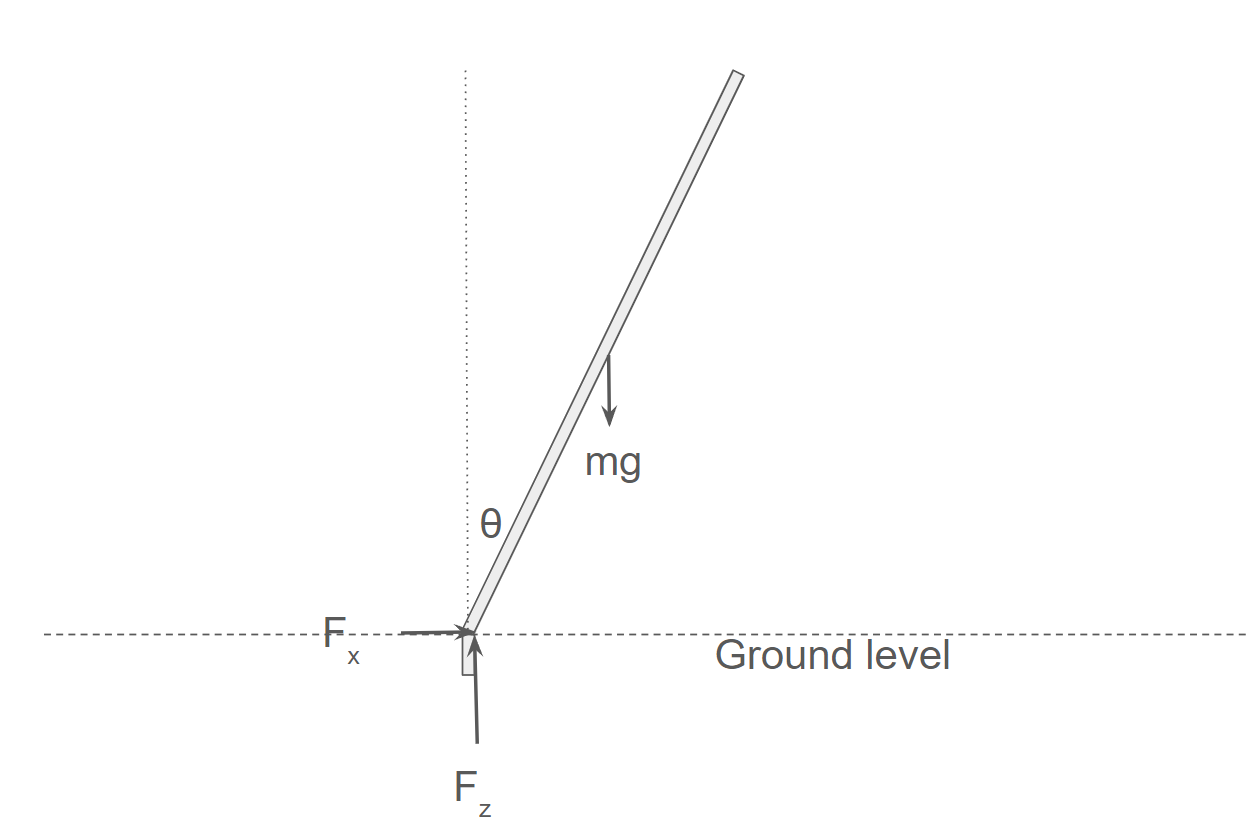

*Setting up the equations*:
Describe everything in terms of the angle of the pole from the vertical, $\theta.$  Then the position of the center of mass is given by $$\vec{x}=\frac{l}{2}(\sin\theta,0,\cos\theta),$$ the velocity of the center of mass is given by 
$$\vec{v}=\frac{l\dot{\theta}}{2}(\cos\theta,0,-\sin\theta),$$ and the acceleration by
$$\vec{a}=\frac{l\dot{\theta}^2}{2}(-\sin\theta,0,-\cos\theta)+\frac{l\ddot{\theta}}{2}(\cos\theta,0,-\sin\theta).$$

The equations of motion are $$F_x=m a_x\implies F_x+\frac{lm\dot{\theta}^2}{2}\sin\theta-\frac{lm\ddot{\theta}}{2}\cos\theta=0$$
$$F_z-mg=m a_z\implies F_z -mg +\frac{lm\dot{\theta}^2}{2}\cos\theta+\frac{lm\ddot{\theta}}{2}\sin\theta=0 $$
and the torque about the center of mass is
$$\tau=I\ddot{\theta} = -\vec{x}\times(F_x,0,F_z)=-l/2\cos\theta F_x+l/2\sin\theta F_z$$

For a given $\theta$ and $\dot{\theta}$ there are three unknowns to go with this set of equations: $\ddot{\theta}$, $F_x$ and $F_z.$  You will need to define a function, deriv, that calculates 
\begin{equation}
\frac{d}{dt}\left(
\begin{array}{c}
\theta\\
\dot{\theta}\\
\end{array}
\right)=
\left(
\begin{array}{c}
\dot{\theta}\\
\ddot{\theta}\\
\end{array}\right)
\end{equation}

To calculate $\ddot{\theta}$ we need to solve this linear set of equations, which we can restate as a matrix equation:
\begin{equation}
\begin{pmatrix}
1 & 0 & -\frac{lm}{2}\cos\theta \\
0 & 1 &\frac{lm}{2}\sin\theta\\
-l/2\cos\theta&l/2\sin\theta &-I\\
\end{pmatrix}
\begin{pmatrix} F_x\\
F_z\\
\ddot{\theta} \end{pmatrix}= \begin{pmatrix} -\frac{lm\dot{\theta}^2}{2}\sin\theta \\
mg -\frac{lm\dot{\theta}^2}{2}\cos\theta \\
0 \\
\end{pmatrix}
\end{equation}

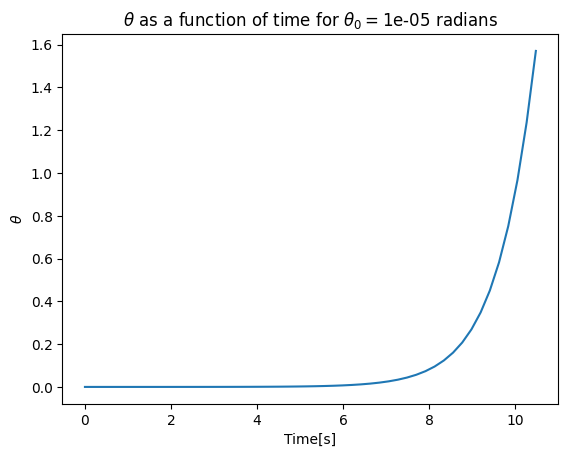

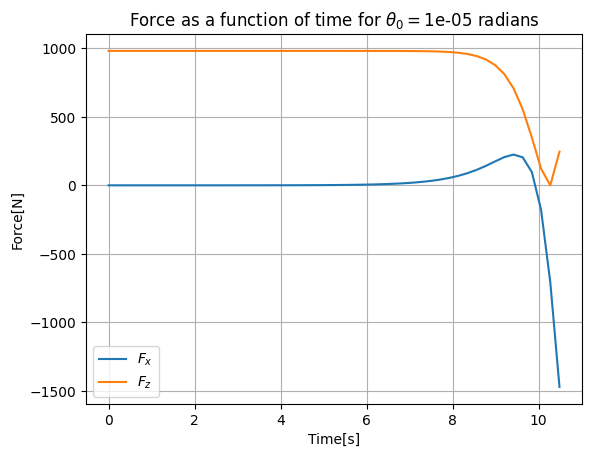

Time for theta_0= 1e-05 is 10.484911909779893 s


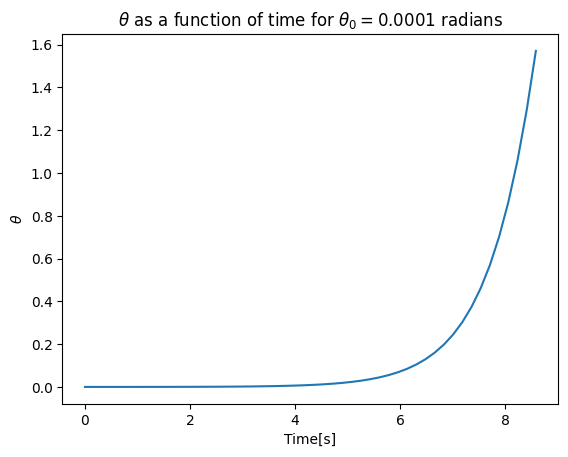

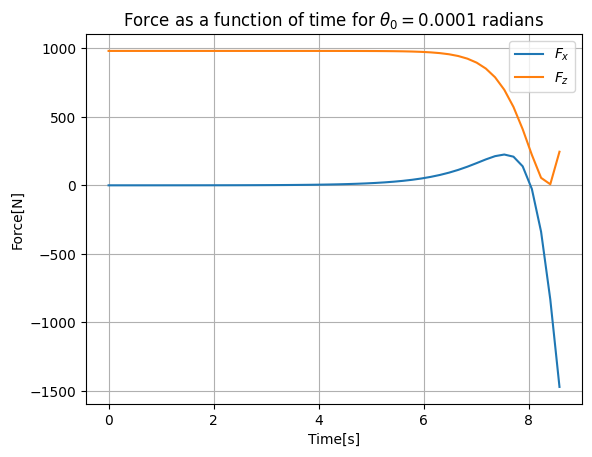

Time for theta_0= 0.0001 is 8.58244677973959 s


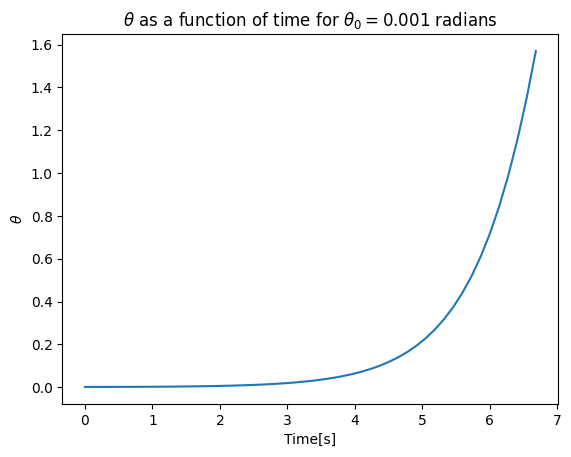

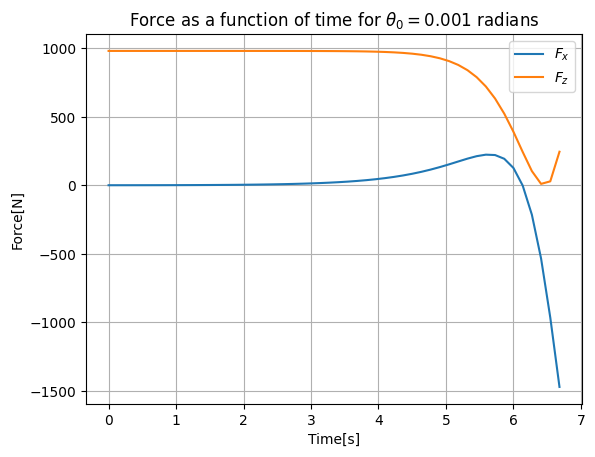

Time for theta_0= 0.001 is 6.683387918936175 s


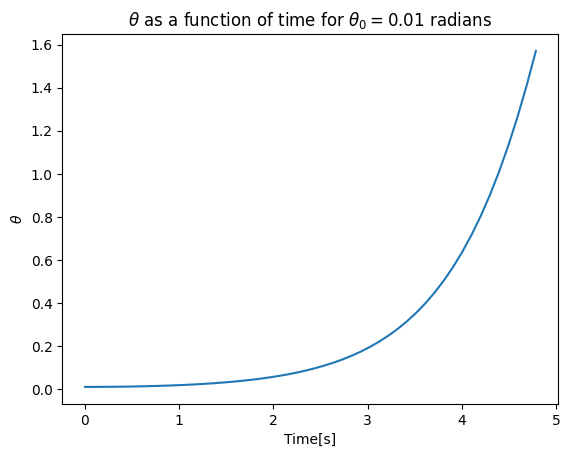

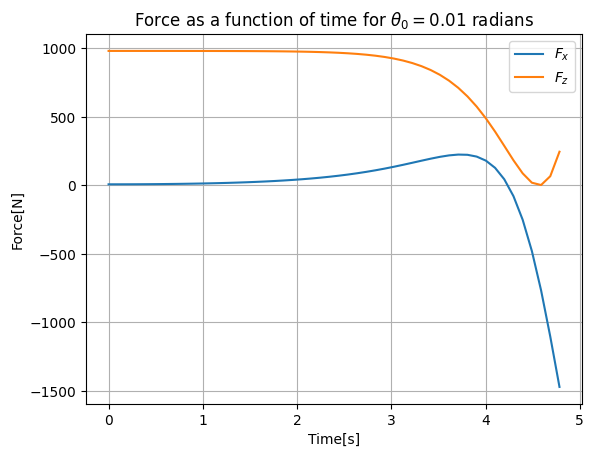

Time for theta_0= 0.01 is 4.784843884083253 s


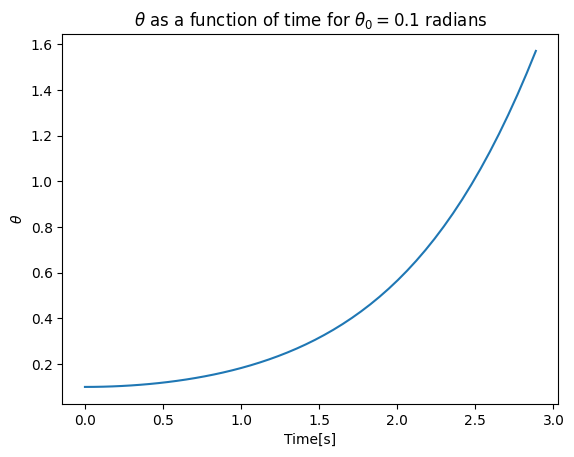

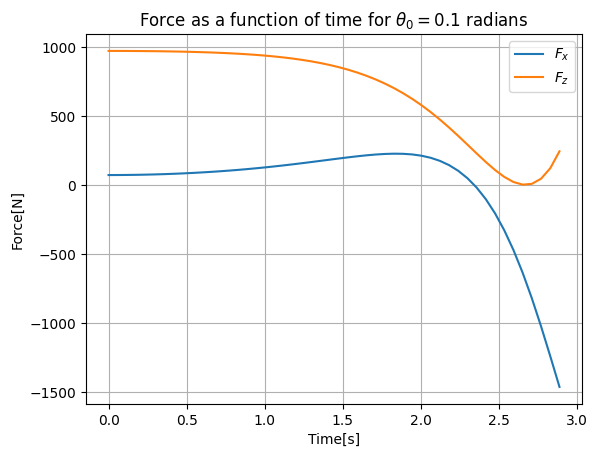

Time for theta_0= 0.1 is 2.8872136137666153 s


In [4]:
from scipy.constants import g
from scipy.integrate import solve_ivp
m=100 #kg
l=10 #m
theta=0.01 #radians
I=m*l**2/12

def hit(t,x):   #we use this function to stop the integration when the pole gets to pi/2
    theta,omega=x
    return theta-np.pi/2
hit.terminal=True

def solve(t,x):  # inverts the matrix and returns Fx,Fz, thetaddot
    global rhs,A,Aminus
    theta,omega=x
    factor=l*m/2
    rhs=np.array([[-factor*np.sin(theta)*omega**2],[-factor*np.cos(theta)*omega**2+m*g],[0]])
    A=np.array([[1,0,-factor*np.cos(theta)],[0,1,factor*np.sin(theta)],[-l/2*np.cos(theta),l/2*np.sin(theta),-I]])
    Aminus=np.linalg.inv(A)
    return Aminus@rhs
    
def deriv(t,x):
    theta,omega=x
    return np.array([omega,solve(t,x)[2,0]])

for theta in (0.00001,0.0001,0.001,0.01,0.1):
    s=solve_ivp(deriv,(0,25),(theta,0),events=hit,dense_output=True,method='DOP853',rtol=1e-8)
    tspace=np.linspace(0,s.t_events[0][0])
    plt.plot(tspace,s.sol(tspace)[0,:])
    plt.title(r"$\theta$ as a function of time for $\theta_0=$"+f'{theta} radians')
    plt.xlabel('Time[s]')
    plt.ylabel(r'$\theta$')
    plt.show()
    plt.plot(tspace,[solve(t, s.sol(t))[0] for t in tspace],label='$F_x$')
    plt.plot(tspace,[solve(t, s.sol(t))[1] for t in tspace],label='$F_z$')
    plt.legend()
    plt.title(r"Force as a function of time for $\theta_0=$"+f'{theta} radians')
    plt.xlabel('Time[s]')
    plt.ylabel('Force[N]')    
    plt.grid()
    plt.show()
    print(f'Time for theta_0= {theta} is {tspace[-1]} s')

## 3. Compton Scattering

Compton scattering is photon-electron scattering and is one of three ways that gamma rays or x-rays interact with matter.

A photon has momentum with magnitude $p=\frac{E}{c},$ where $E$ is the energy and $c$ is the speed of light. Relativistically, the relationship between energy and momentum is $E=\sqrt{p^2c^2+m^2c^4}$

A photon with energy $E$ scatters from an electron at rest, and leaves with energy $E'$ at a scattering angle $\theta$, as shown in the figure below. 

3a. Define the function Out(E, theta), by *numerically* solving the equations for conservation of energy and momentum.  Out(E,theta) should return an tuple (E',p_e, theta_e), where p_e is the magnitude of the electron momentum and theta_e is the electron scattering angle.  Plot E', p_e, and theta_e as a function of theta for $E=1.5 MeV.$ Overlay the analytic result for Compton scattering: $$E'=\frac{E}{1+\frac{E}{m_ec^2} (1-\cos\theta)}$$ 

The electron has $m_e c^2=0.51099895~\rm{MeV}.$  If you leave energies and rest-mass energy equivalents in units of MeV, and momentum in units of MeV/c, you can set $c=1$ in the equations.  

The relevant equations are conservation of energy and conservation of momentum:
$$E+m_ec^2=E'+E_e$$
$$\vec{p}=\vec{p}'+\vec{p}_e,$$
where the incoming photon has energy and momentum $E,\vec{p},$ the outgoing photon has energy and momentum $E',\vec{p}',$ and the outgoing electron has energy and momentum $E_e, \vec{p}_e.$

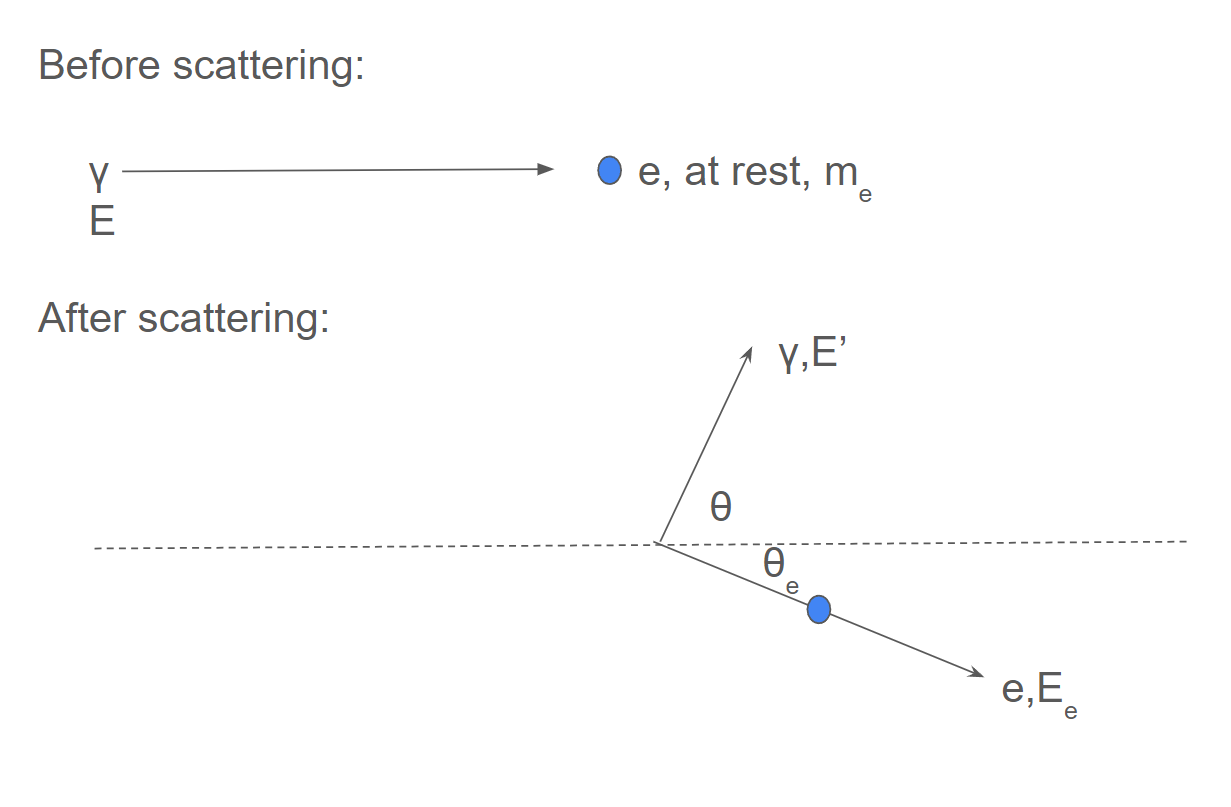

### Numerical Hint
The obvious way to do this would be to use scipy.optimize.roots.  However, it turns out that the numerical solutions allow cases where the electron energy is negative.  There is a physical minimum to E'. You are better off using scipy.optimize.minimize, which allows you to set bounds on the solution.  You might still find that there is some sensitivity to the starting values, but one can find starting values that allow for good solutions over the entire range of theta.  


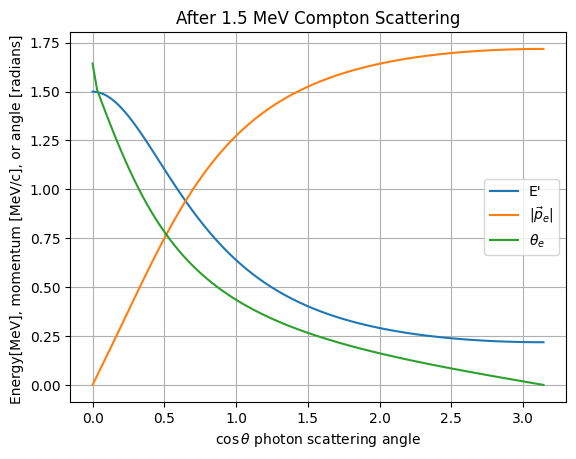

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.constants import find,value,c
me=value('electron mass energy equivalent in MeV')
re=value('classical electron radius')

def dP(x,E,theta):
    Eprime,thetae=x
    p=E*np.array([1,0]) #incoming photon momentum
    pprime=Eprime*np.array([np.cos(theta),np.sin(theta)]) #outgoing photon momentum
    Ee=me+E-Eprime
    de=Ee**2-me**2
    if de<0:
        de=0.0
    pe=np.sqrt(de)*np.array([np.cos(thetae),-np.sin(thetae)]) #outgoing electron momentum
#    print(Eprime,phi,p,pprime,pe,de)
    return np.linalg.norm(p-pprime-pe)  #length of difference in momentum vectors

def Eout(E,theta):
    global sol
#    print('eout',E,theta)
    sol=minimize(dP,np.array([E/2,2*np.pi/3]),args=(E,theta),bounds=((Emin,E),(0,np.pi)),tol=1e-10)
    Eprime,thetae=sol.x
    return (Eprime,np.sqrt((E-Eprime+me)**2-me**2),thetae)

Emin=0 # needs to be set in order to call Eout
Emin=Eout(1.5,np.pi)[0]  #  minimum photon energy is when gamma bounces straight back
thlist=np.linspace(0.,np.pi,100)
ll=np.array([Eout(1.5,th) for th in thlist])
plt.plot(thlist,ll[:,0],label="E'")
plt.plot(thlist,ll[:,1],label=r"$|\vec{p}_e|$")
plt.plot(thlist,ll[:,2],label=r"$\theta_e$")
plt.legend()
plt.title("After 1.5 MeV Compton Scattering")
plt.xlabel(r'$\cos\theta$ photon scattering angle')
plt.ylabel("Energy[MeV], momentum [MeV/c], or angle [radians] ")
plt.grid()

3b. The Klein-Nishina formula gives the differential cross section for Compton scattering; this is the cross section for photons to scatter into a particular direction: $d\Omega=\sin\theta d\theta d\phi=d\cos\theta d\phi.$ 

$${\displaystyle {\frac {d\sigma }{d\Omega }}={\frac {1}{2}}r_{e}^{2}\left({\frac {\lambda }{\lambda '}}\right)^{2}\left[{\frac {\lambda }{\lambda '}}+{\frac {\lambda '}{\lambda }}-\sin ^{2}(\theta )\right]}$$

Here $r_e=2.8179403262\times 10^{-15}~\rm{m},$ the classical electron radius. 

As a reminder, the *cross section* is a measure of the probability of an interaction.  It has units of area since the mean number of interactions,  $\bar{n}=N\sigma t$, where $N$ is the number of target particles per cubic meter, $\sigma$ the cross section with units of area, and $t$ the distance the particle travels.

We rewrite Klein-Nishina in terms of energy using Planck's law $E=h\nu$ and $\lambda \nu =c \implies E= \frac{hc}{\lambda}$

$${\displaystyle {\frac {d\sigma }{d\Omega }}={\frac {1}{2}}r_{e}^{2}\left({\frac {E' }{E}}\right)^{2}\left[{\frac {E' }{E}}+{\frac {E}{E'}}-\sin ^{2}(\theta )\right]}$$

Plot this cross section as a function of $\cos\theta$ for at least five starting photon energies ranging from 0.1 to 10 MeV.  In addition to the Klein Nishina formula, you will need to use the results from question 3a or the analytic formula from 3a to relate E' to $\cos\theta$. 

*Note*  With the analytic formula, you can do this even if you were unable to do 3a.


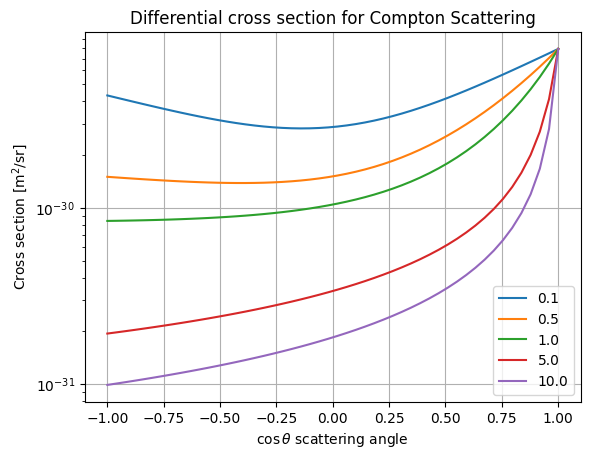

In [126]:
def ep(ct,E):
    return E/(1+E/me*(1-ct))
def dcs(ct,E):
    eprime=ep(ct,E)
    ratio=eprime/E
    return 0.5*re**2*ratio**2*(ratio+1/ratio-1+ct**2)

ctlist=np.linspace(-1,1)
elist=np.array([0.1,0.5,1,5,10])
for E in elist:
    plt.plot(ctlist,[dcs(c,E) for c in ctlist],label=f'{E}')
plt.title("Differential cross section for Compton Scattering")
plt.xlabel(r"$\cos\theta$ scattering angle")
plt.ylabel("Cross section [m$^2$/sr]")
plt.legend()
plt.grid()
plt.yscale('log')
plt.show()


3c. Integrate the differential cross section to get a total cross section:

$$\sigma=\int_{-1}^{1}\int_{0}^{2\pi}\frac{d\sigma}{d\Omega}d\phi d(\cos\theta)$$ 

Since the integrand has no $\phi$ dependence, the $\phi$-integral is trivial and we end up with a single integral: 

$$\sigma=2\pi\int_{-1}^{1}\frac{d\sigma}{d\Omega} d(\cos\theta)$$ 

Define a function XS(E) that performs this integral to get the total cross section for gamma-ray scattering on electrons for gammas.  Plot XS as a function of E between 0.1 and 10 MeV.  

Note With the analytic formula, you can do this even if you were unable to do 3a.

Text(0, 0.5, 'Cross section [m$^2$]')

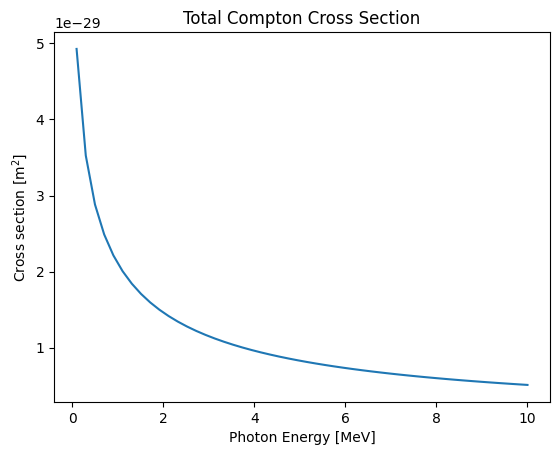

In [93]:
from scipy.integrate import quad
def XS(E):
    return 2*np.pi*quad(dcs,-1,1, args=E)[0]

elist=np.linspace(0.1,10)
plt.plot(elist, [XS(e) for e in elist])
plt.title("Total Compton Cross Section")
plt.xlabel("Photon Energy [MeV]")
plt.ylabel("Cross section [m$^2$]")

3d. Each water molecule has 10 electrons, and a mole of water weighs 18g.  Calculate and plot the mean distance photons will travel before Compton scattering and plot the distance versus photon energy, for photon energies between 0.1 and 10 MeV.

In [ ]:
A=value('Avogadro constant')  #from scipy.constants
N=10*A/18 * 1 *1e6#electrons/molecule x molecules/mole /grams /mole * grams/cm**3 *m**3/cm**3= electrons/m**3
def d(E):
    return 1.0/(N*XS(E))
plt.plot(elist, [d(e) for e in elist])
plt.title("Compton Scattering Length")
plt.xlabel("Photon Energy [MeV]")
plt.ylabel("Scattering Length [m${-1}$]")

3e. Suppose 100000 1 MeV photons Compton scatter.  Write a MC algorithm that throws scattering angles according to the distribution in 3b).  Histogram the scattering angle and E'.  

In [115]:
# Use throw and pick method

cts=rng.uniform(size=1000000)*2-1 # a million points between -1 and 1
cut=rng.uniform(size=1000000)*dcs(1.0,1.0)  # dcs(1,1) because maximum cross section is at cos theta=1.0
dc=np.array([dcs(c,1.0) for c in cts])
good=cts[np.asarray(dc>cut).nonzero()[0]]

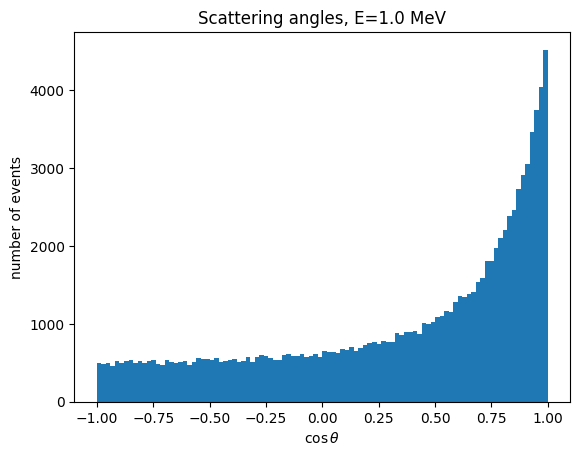

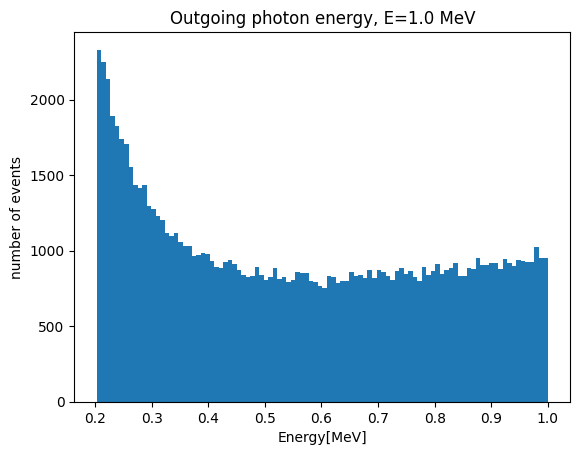

In [124]:
plt.hist(good[:100000],100)
plt.title("Scattering angles, E=1.0 MeV")
plt.xlabel(r"$\cos\theta$")
plt.ylabel("number of events")
plt.show()
plt.hist(ep(good[:100000],1.0),100)  # use analytic formula to get outgoing photon energy
plt.title("Outgoing photon energy, E=1.0 MeV")
plt.xlabel("Energy[MeV]")
plt.ylabel("number of events")
plt.show()